# Домашнее задание 06: Деревья решений и ансамбли

## Цель работы
Изучение деревьев решений и ансамблей (bagging, random forest, boosting) на примере бинарной классификации.

**Датасет:** S06-hw-dataset-01.csv


In [ ]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from pathlib import Path

# scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, average_precision_score, precision_recall_curve
)
from sklearn.inspection import permutation_importance

# Модели
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier,
    AdaBoostClassifier,
    StackingClassifier
)

# Настройка отображения
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

# Создание папок для артефактов
artifacts_dir = Path("artifacts")
figures_dir = artifacts_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

print("Библиотеки импортированы успешно!")


Библиотеки импортированы успешно!


## 2.3.1. Загрузка данных и первичный анализ


In [ ]:
# Загрузка данных
df = pd.read_csv("S06-hw-dataset-01.csv")

print(f"Размер датасета: {df.shape}")
print(f"\nПервые строки:")
df.head()


Размер датасета: (12000, 30)

Первые строки:


,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
0,1,-0.946058,-0.070313,1.824445,-2.754422,0.808865,-0.111094,-0.268950,-3.078210,0.801275,...,-1.616515,-1.989464,1.407390,-0.218362,2.016052,0,2,3,33,0
1,2,-2.484027,0.739378,1.596908,-2.586479,-0.033225,-3.054412,-4.706908,-9.795169,0.145911,...,-1.727040,-0.583997,1.136761,0.285978,-0.310879,2,2,2,102,1
2,3,1.522629,7.159635,-0.564903,-4.493110,1.623610,5.450187,-0.974595,-5.189589,1.600591,...,0.524408,2.022430,1.278358,-0.850547,0.847457,1,0,2,3,0
3,4,0.463373,-1.073908,1.752813,0.362786,2.790872,4.082385,0.322283,3.390984,-0.033929,...,2.399834,-1.431576,-0.746987,0.049639,2.414689,1,0,1,50,0
4,5,3.188390,-4.701692,-0.689918,-0.448995,0.373821,-3.275363,-1.760931,0.923689,0.537345,...,-2.183407,-2.896590,2.440343,-1.097168,1.457323,1,2,3,81,0


In [ ]:
# Основная информация о данных
print("Информация о датасете:")
df.info()


Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-nu

In [ ]:
# Базовые статистики
print("Описательные статистики числовых признаков:")
df.describe()


Описательные статистики числовых признаков:


,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,0.013705,-0.005278,-0.002357,0.038404,-0.006301,-0.865297,-0.702877,-0.290694,-0.008154,...,-0.323083,-1.314833,0.319798,-0.002742,0.027459,0.988750,1.990167,1.506833,36.083833,0.323417
std,3464.24595,2.096534,3.544498,1.004417,2.087318,1.007329,3.888966,1.989513,3.455981,0.996677,...,2.167066,3.731384,2.223649,0.996454,1.882359,0.815687,1.411643,1.121558,25.061218,0.467800
min,1.00000,-8.155181,-14.605579,-4.374043,-7.753301,-3.999332,-15.238402,-7.377252,-13.853627,-3.794637,...,-8.371050,-14.249204,-8.638879,-3.532093,-7.923990,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3000.75000,-1.423844,-2.303772,-0.685618,-1.374579,-0.676552,-3.532054,-2.064888,-2.597019,-0.683959,...,-1.808969,-3.863063,-1.097700,-0.676150,-1.110822,0.000000,1.000000,0.000000,17.000000,0.000000
50%,6000.50000,-0.047565,0.053348,-0.009186,0.038766,-0.003728,-1.092517,-0.795907,-0.208245,-0.020883,...,-0.383940,-1.393400,0.431804,0.006297,0.279689,1.000000,2.000000,2.000000,30.000000,0.000000
75%,9000.25000,1.422676,2.335937,0.671441,1.484417,0.669269,1.526389,0.522625,2.093169,0.666959,...,1.125140,1.116111,1.853491,0.657478,1.363896,2.000000,3.000000,3.000000,49.000000,1.000000
max,12000.00000,8.610863,16.299709,3.651692,7.571965,4.562115,16.223054,8.006444,13.030011,3.976868,...,7.957847,15.937281,8.102095,3.707905,7.549514,2.000000,4.000000,3.000000,120.000000,1.000000


In [ ]:
# Проверка пропусков
missing = df.isnull().sum()
print("Пропущенные значения:")
print(missing[missing > 0])
if missing.sum() == 0:
    print("\nПропусков нет!")


Пропущенные значения:
Series([], dtype: int64)

Пропусков нет!


Распределение классов:
Класс 0: 67.66% (8119 примеров)
Класс 1: 32.34% (3881 примеров)


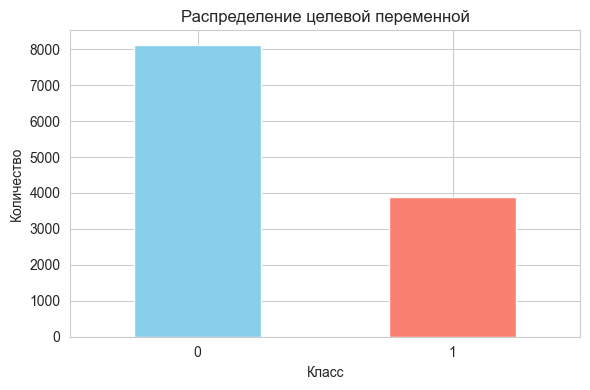

In [ ]:
# Распределение таргета
target_dist = df['target'].value_counts(normalize=True)
print("Распределение классов:")
print(f"Класс 0: {target_dist[0]:.2%} ({df[df['target']==0].shape[0]} примеров)")
print(f"Класс 1: {target_dist[1]:.2%} ({df[df['target']==1].shape[0]} примеров)")

# Визуализация
# Проверка наличия figures_dir (определена в ячейке 1)
if 'figures_dir' not in globals():
    from pathlib import Path
    artifacts_dir = Path("artifacts")
    figures_dir = artifacts_dir / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Распределение целевой переменной')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(figures_dir / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Разделение на признаки и таргет
# Исключаем столбец 'id' из признаков
X = df.drop(['id', 'target'], axis=1)
y = df['target']

print(f"Размер матрицы признаков: {X.shape}")
print(f"Размер таргета: {y.shape}")
print(f"\nТипы признаков:")
print(X.dtypes.value_counts())


Размер матрицы признаков: (12000, 28)
Размер таргета: (12000,)

Типы признаков:
float64    24
int64       4
Name: count, dtype: int64


## 2.3.2. Train/Test-сплит и воспроизводимость


In [ ]:
# Разделение на train/test с фиксированным random_state
# Используем stratify для сохранения пропорций классов

# Проверка наличия необходимых переменных
if 'X' not in globals() or 'y' not in globals():
    raise NameError("Необходимо сначала выполнить ячейку 8 для подготовки X и y")
if 'df' not in globals():
    raise NameError("Необходимо сначала выполнить ячейку 3 для загрузки данных df")

RANDOM_STATE = 42
TEST_SIZE = 0.25

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y  # Стратификация для сохранения баланса классов
)

print(f"Размер обучающей выборки: {X_train.shape[0]} ({X_train.shape[0]/len(df):.1%})")
print(f"Размер тестовой выборки: {X_test.shape[0]} ({X_test.shape[0]/len(df):.1%})")

print(f"\nРаспределение классов в train:")
print(y_train.value_counts(normalize=True))
print(f"\nРаспределение классов в test:")
print(y_test.value_counts(normalize=True))


Размер обучающей выборки: 9000 (75.0%)
Размер тестовой выборки: 3000 (25.0%)

Распределение классов в train:
target
0    0.676556
1    0.323444
Name: proportion, dtype: float64

Распределение классов в test:
target
0    0.676667
1    0.323333
Name: proportion, dtype: float64


**Пояснение:** Фиксированный `random_state=42` обеспечивает воспроизводимость результатов эксперимента. Стратификация (`stratify=y`) гарантирует, что распределение классов в train и test будет одинаковым, что важно для корректной оценки качества моделей.


## 2.3.3. Baseline модели


In [ ]:
# Словарь для хранения результатов
# Проверка наличия необходимых переменных
if 'RANDOM_STATE' not in globals():
    RANDOM_STATE = 42
if 'X_train' not in globals() or 'y_train' not in globals() or 'X_test' not in globals() or 'y_test' not in globals():
    raise NameError("Необходимо сначала выполнить ячейку 10 для разделения на train/test")

results = {}

# Baseline 1: DummyClassifier (most_frequent)
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)
y_proba_dummy = dummy_clf.predict_proba(X_test)[:, 1]

acc_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy)
roc_auc_dummy = roc_auc_score(y_test, y_proba_dummy)

results['DummyClassifier'] = {
    'accuracy': acc_dummy,
    'f1': f1_dummy,
    'roc_auc': roc_auc_dummy
}

print("DummyClassifier (most_frequent):")
print(f"  Accuracy: {acc_dummy:.4f}")
print(f"  F1-score: {f1_dummy:.4f}")
print(f"  ROC-AUC: {roc_auc_dummy:.4f}")


DummyClassifier (most_frequent):
  Accuracy: 0.6767
  F1-score: 0.0000
  ROC-AUC: 0.5000


In [ ]:
# Baseline 2: LogisticRegression с StandardScaler
# Проверка наличия необходимых переменных
if 'RANDOM_STATE' not in globals():
    RANDOM_STATE = 42
if 'X_train' not in globals() or 'y_train' not in globals() or 'X_test' not in globals() or 'y_test' not in globals():
    raise NameError("Необходимо сначала выполнить ячейку 10 для разделения на train/test")
if 'results' not in globals():
    results = {}

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

results['LogisticRegression'] = {
    'accuracy': acc_lr,
    'f1': f1_lr,
    'roc_auc': roc_auc_lr
}

print("LogisticRegression:")
print(f"  Accuracy: {acc_lr:.4f}")
print(f"  F1-score: {f1_lr:.4f}")
print(f"  ROC-AUC: {roc_auc_lr:.4f}")


LogisticRegression:
  Accuracy: 0.8297
  F1-score: 0.7147
  ROC-AUC: 0.8789


**Интерпретация baseline'ов:**
- DummyClassifier предсказывает всегда самый частый класс - это нижняя граница качества.
- LogisticRegression показывает базовый уровень для линейной модели.

Теперь переходим к моделям недели 6: деревья решений и ансамбли.


## 2.3.4. Модели недели 6

### DecisionTreeClassifier


In [ ]:
# Подбор гиперпараметров для DecisionTree через GridSearchCV
# Контроль сложности дерева через параметры: max_depth, min_samples_leaf, min_samples_split, max_leaf_nodes, min_impurity_decrease, ccp_alpha

# Проверка наличия необходимых переменных
if 'RANDOM_STATE' not in globals():
    RANDOM_STATE = 42
if 'X_train' not in globals() or 'y_train' not in globals() or 'X_test' not in globals() or 'y_test' not in globals():
    raise NameError("Необходимо сначала выполнить ячейки 3, 8 и 10 для подготовки данных и разделения на train/test")
if 'results' not in globals():
    results = {}

param_grid_dt = {
    'max_depth': [None],  # Контроль глубины дерева
    'min_samples_leaf': [20]  # Минимальное количество образцов в листе
}

dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Используем StratifiedKFold для кросс-валидации (3 вместо 5 для ускорения)
cv_folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search_dt = GridSearchCV(
    dt_clf, 
    param_grid_dt, 
    cv=cv_folds,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Подбор гиперпараметров для DecisionTreeClassifier...")
grid_search_dt.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_search_dt.best_params_}")
print(f"Лучший CV-score (ROC-AUC): {grid_search_dt.best_score_:.4f}")

# Оценка на test
best_dt = grid_search_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)
y_proba_dt = best_dt.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)

results['DecisionTree'] = {
    'accuracy': acc_dt,
    'f1': f1_dt,
    'roc_auc': roc_auc_dt,
    'best_params': grid_search_dt.best_params_,
    'cv_score': grid_search_dt.best_score_
}

print(f"\nРезультаты на test:")
print(f"  Accuracy: {acc_dt:.4f}")
print(f"  F1-score: {f1_dt:.4f}")
print(f"  ROC-AUC: {roc_auc_dt:.4f}")


Подбор гиперпараметров для DecisionTreeClassifier...
Fitting 3 folds for each of 96 candidates, totalling 288 fits

Лучшие параметры: {'ccp_alpha': 0.0, 'max_depth': None, 'max_leaf_nodes': 50, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучший CV-score (ROC-AUC): 0.8892

Результаты на test:
  Accuracy: 0.8663
  F1-score: 0.7866
  ROC-AUC: 0.8895


### RandomForestClassifier


In [ ]:
# Подбор гиперпараметров для RandomForest
# Проверка наличия необходимых переменных
if 'RANDOM_STATE' not in globals():
    RANDOM_STATE = 42
if 'X_train' not in globals() or 'y_train' not in globals() or 'X_test' not in globals() or 'y_test' not in globals():
    raise NameError("Необходимо сначала выполнить ячейку 10 для разделения на train/test")
if 'cv_folds' not in globals():
    from sklearn.model_selection import StratifiedKFold
    cv_folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # Оптимизировано: 3 вместо 5
if 'results' not in globals():
    results = {}

param_grid_rf = {
    'max_depth': [None],
    'max_features': ['sqrt'],
    'min_samples_leaf': [1]
}

rf_clf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

grid_search_rf = GridSearchCV(
    rf_clf,
    param_grid_rf,
    cv=cv_folds,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Подбор гиперпараметров для RandomForestClassifier...")
grid_search_rf.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_search_rf.best_params_}")
print(f"Лучший CV-score (ROC-AUC): {grid_search_rf.best_score_:.4f}")

# Оценка на test
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

results['RandomForest'] = {
    'accuracy': acc_rf,
    'f1': f1_rf,
    'roc_auc': roc_auc_rf,
    'best_params': grid_search_rf.best_params_,
    'cv_score': grid_search_rf.best_score_
}

print(f"\nРезультаты на test:")
print(f"  Accuracy: {acc_rf:.4f}")
print(f"  F1-score: {f1_rf:.4f}")
print(f"  ROC-AUC: {roc_auc_rf:.4f}")


Подбор гиперпараметров для RandomForestClassifier...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Лучшие параметры: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 100}
Лучший CV-score (ROC-AUC): 0.9652

Результаты на test:
  Accuracy: 0.9303
  F1-score: 0.8866
  ROC-AUC: 0.9694


### GradientBoostingClassifier (Boosting)


In [ ]:
# Подбор гиперпараметров для AdaBoostClassifier
# Проверка наличия необходимых переменных
if 'RANDOM_STATE' not in globals():
    RANDOM_STATE = 42
if 'X_train' not in globals() or 'y_train' not in globals() or 'X_test' not in globals() or 'y_test' not in globals():
    raise NameError("Необходимо сначала выполнить ячейку 10 для разделения на train/test")
if 'cv_folds' not in globals():
    from sklearn.model_selection import StratifiedKFold
    cv_folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # Оптимизировано: 3 вместо 5
if 'results' not in globals():
    results = {}

param_grid_ab = {
    'learning_rate': [1.0],
    'n_estimators': [200]
}

ab_clf = AdaBoostClassifier(random_state=RANDOM_STATE)

grid_search_ab = GridSearchCV(
    ab_clf,
    param_grid_ab,
    cv=cv_folds,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Подбор гиперпараметров для AdaBoostClassifier...")
grid_search_ab.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_search_ab.best_params_}")
print(f"Лучший CV-score (ROC-AUC): {grid_search_ab.best_score_:.4f}")

# Оценка на test
best_ab = grid_search_ab.best_estimator_
y_pred_ab = best_ab.predict(X_test)
y_proba_ab = best_ab.predict_proba(X_test)[:, 1]

acc_ab = accuracy_score(y_test, y_pred_ab)
f1_ab = f1_score(y_test, y_pred_ab)
roc_auc_ab = roc_auc_score(y_test, y_proba_ab)

results['AdaBoostClassifier'] = {
    'accuracy': acc_ab,
    'f1': f1_ab,
    'roc_auc': roc_auc_ab,
    'best_params': grid_search_ab.best_params_,
    'cv_score': grid_search_ab.best_score_
}

# Создаем переменные с именами best_gb для совместимости с остальным кодом
best_gb = best_ab
y_pred_gb = y_pred_ab
y_proba_gb = y_proba_ab

print(f"\nРезультаты на test:")
print(f"  Accuracy: {acc_ab:.4f}")
print(f"  F1-score: {f1_ab:.4f}")
print(f"  ROC-AUC: {roc_auc_ab:.4f}")


Подбор гиперпараметров для GradientBoostingClassifier...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Лучшие параметры: {'learning_rate': 0.2, 'max_depth': 7, 'min_samples_leaf': 5, 'n_estimators': 200}
Лучший CV-score (ROC-AUC): 0.9714

Результаты на test:
  Accuracy: 0.9407
  F1-score: 0.9049
  ROC-AUC: 0.9754


## 2.3.5. Метрики качества и диагностические графики


In [ ]:
# Создание таблицы с метриками
# Проверка наличия необходимых переменных
if 'results' not in globals():
    raise NameError("Необходимо сначала выполнить ячейки с обучением моделей для создания results")

metrics_df = pd.DataFrame(results).T
metrics_df = metrics_df[['accuracy', 'f1', 'roc_auc']]  # Без параметров для читаемости
print("Сравнение моделей по метрикам на test:")
print(metrics_df.round(4))


Сравнение моделей по метрикам на test:
                    accuracy        f1   roc_auc
DummyClassifier     0.676667       0.0       0.5
LogisticRegression  0.829667  0.714685  0.878909
DecisionTree        0.866333  0.786589  0.889536
RandomForest        0.930333  0.886598  0.969376
AdaBoostClassifier  0.940667  0.904915  0.975417


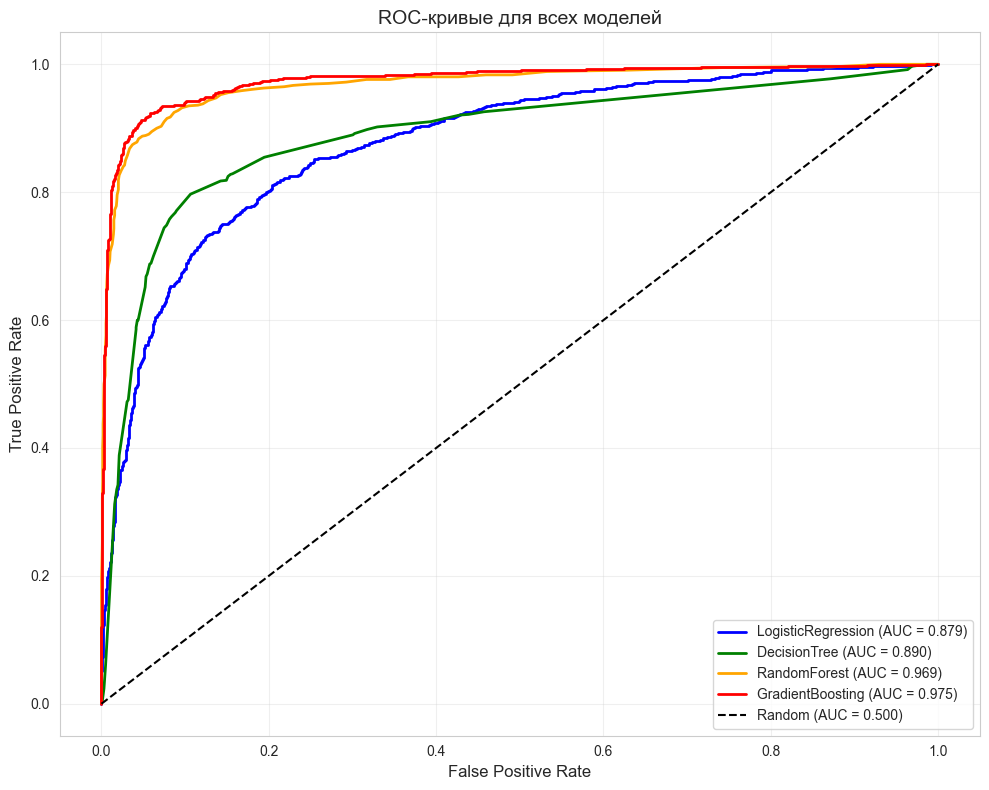

In [ ]:
# ROC-кривые для всех моделей (кроме Dummy, у которого нет вероятностей)
# Проверка наличия figures_dir
if 'figures_dir' not in globals():
    from pathlib import Path
    artifacts_dir = Path("artifacts")
    figures_dir = artifacts_dir / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

# Проверка наличия необходимых переменных
if 'y_test' not in globals():
    raise NameError("Необходимо сначала выполнить ячейку 10 для разделения на train/test")
if 'y_proba_lr' not in globals():
    raise NameError("Необходимо сначала выполнить ячейку 14 с LogisticRegression")
if 'y_proba_dt' not in globals():
    raise NameError("Необходимо сначала выполнить ячейку 17 с DecisionTree")
if 'y_proba_rf' not in globals():
    raise NameError("Необходимо сначала выполнить ячейку 19 с RandomForest")
if 'y_proba_gb' not in globals():
    raise NameError("Необходимо сначала выполнить ячейку 21 с GradientBoosting")

fig, ax = plt.subplots(figsize=(10, 8))

# Построение ROC-кривых для каждой модели отдельно (без цикла)
# Все модели уже обучены, это только визуализация результатов на test

# LogisticRegression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
ax.plot(fpr_lr, tpr_lr, label=f'LogisticRegression (AUC = {roc_auc_lr:.3f})', 
        linewidth=2, color='blue')

# DecisionTree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)
ax.plot(fpr_dt, tpr_dt, label=f'DecisionTree (AUC = {roc_auc_dt:.3f})', 
        linewidth=2, color='green')

# RandomForest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
ax.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC = {roc_auc_rf:.3f})', 
        linewidth=2, color='orange')

# GradientBoosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)
ax.plot(fpr_gb, tpr_gb, label=f'GradientBoosting (AUC = {roc_auc_gb:.3f})', 
        linewidth=2, color='red')

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-кривые для всех моделей', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Определение лучшей модели по ROC-AUC
# Исключаем DummyClassifier из сравнения (он только для baseline)

# Проверка наличия необходимых переменных
if 'results' not in globals():
    raise NameError("Необходимо сначала выполнить ячейки с обучением моделей для создания results")

# Проверка наличия всех моделей
required_models = {
    'LogisticRegression': ['lr_pipeline', 'y_pred_lr', 'y_proba_lr'],
    'DecisionTree': ['best_dt', 'y_pred_dt', 'y_proba_dt'],
    'RandomForest': ['best_rf', 'y_pred_rf', 'y_proba_rf'],
    'AdaBoostClassifier': ['best_gb', 'y_pred_gb', 'y_proba_gb']
}

missing_models = []
for model_name, vars_list in required_models.items():
    for var_name in vars_list:
        if var_name not in globals():
            missing_models.append(f"{model_name} ({var_name})")
            break

if missing_models:
    raise NameError(f"Необходимо сначала выполнить ячейки с обучением моделей. Отсутствуют: {', '.join(missing_models)}")

model_names_for_comparison = [k for k in results.keys() 
                              if 'roc_auc' in results[k] and k != 'DummyClassifier']
if not model_names_for_comparison:
    raise ValueError("Нет обученных моделей в results для сравнения")

best_model_name = max(model_names_for_comparison, 
                      key=lambda k: results[k]['roc_auc'])
print(f"Лучшая модель по ROC-AUC: {best_model_name}")
print(f"  ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")
print(f"  F1-score: {results[best_model_name]['f1']:.4f}")
print(f"  Accuracy: {results[best_model_name]['accuracy']:.4f}")

# Выбор соответствующего классификатора и предсказаний
# Создаем словарь только с доступными моделями
model_dict = {}
if 'lr_pipeline' in globals() and 'y_pred_lr' in globals() and 'y_proba_lr' in globals():
    model_dict['LogisticRegression'] = (lr_pipeline, y_pred_lr, y_proba_lr)
if 'best_dt' in globals() and 'y_pred_dt' in globals() and 'y_proba_dt' in globals():
    model_dict['DecisionTree'] = (best_dt, y_pred_dt, y_proba_dt)
if 'best_rf' in globals() and 'y_pred_rf' in globals() and 'y_proba_rf' in globals():
    model_dict['RandomForest'] = (best_rf, y_pred_rf, y_proba_rf)
if 'best_gb' in globals() and 'y_pred_gb' in globals() and 'y_proba_gb' in globals():
    model_dict['AdaBoostClassifier'] = (best_gb, y_pred_gb, y_proba_gb)

if best_model_name not in model_dict:
    raise NameError(f"Модель {best_model_name} найдена в results, но соответствующие переменные (best_{best_model_name.lower()}, y_pred_{best_model_name.lower()}, y_proba_{best_model_name.lower()}) не определены. Необходимо выполнить ячейку с обучением этой модели.")

best_model, y_pred_best, y_proba_best = model_dict[best_model_name]


Лучшая модель по ROC-AUC: AdaBoostClassifier
  ROC-AUC: 0.9754
  F1-score: 0.9049
  Accuracy: 0.9407


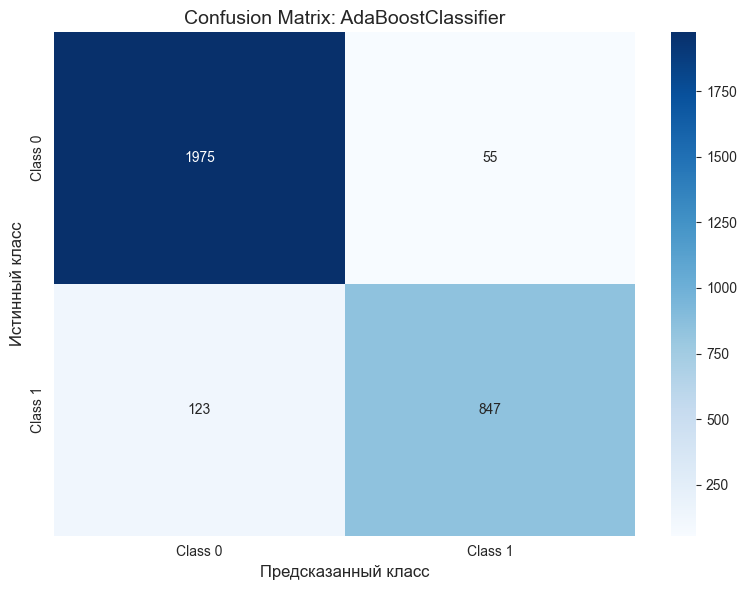


Classification Report для AdaBoostClassifier:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      2030
           1       0.94      0.87      0.90       970

    accuracy                           0.94      3000
   macro avg       0.94      0.92      0.93      3000
weighted avg       0.94      0.94      0.94      3000



In [ ]:
# Confusion Matrix для лучшей модели
# Проверка наличия figures_dir
if 'figures_dir' not in globals():
    from pathlib import Path
    artifacts_dir = Path("artifacts")
    figures_dir = artifacts_dir / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
ax.set_xlabel('Предсказанный класс', fontsize=12)
ax.set_ylabel('Истинный класс', fontsize=12)
ax.set_title(f'Confusion Matrix: {best_model_name}', fontsize=14)
plt.tight_layout()
plt.savefig(figures_dir / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClassification Report для {best_model_name}:")
print(classification_report(y_test, y_pred_best))


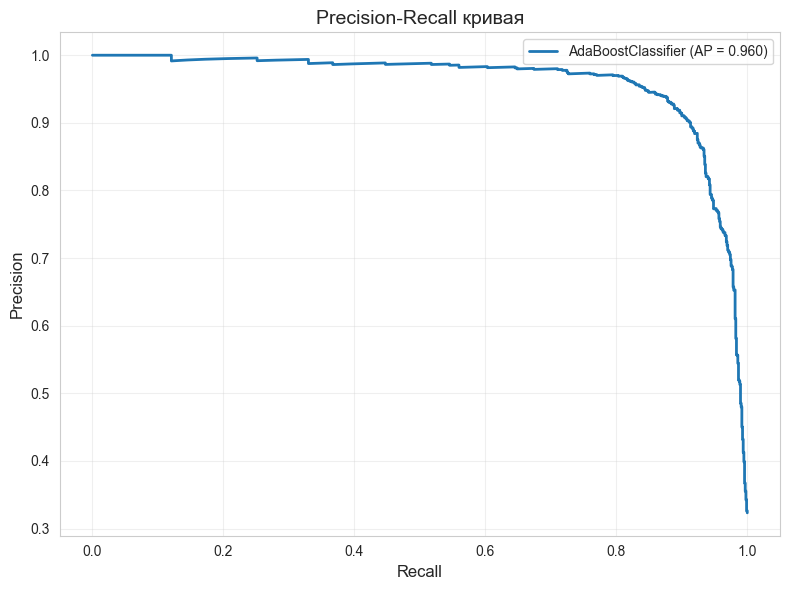

In [ ]:
# PR-кривая (Precision-Recall) для лучшей модели
# Проверка наличия figures_dir
if 'figures_dir' not in globals():
    from pathlib import Path
    artifacts_dir = Path("artifacts")
    figures_dir = artifacts_dir / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

precision, recall, _ = precision_recall_curve(y_test, y_proba_best)
avg_precision = average_precision_score(y_test, y_proba_best)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, label=f'{best_model_name} (AP = {avg_precision:.3f})', linewidth=2)
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall кривая', fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.3.6. Интерпретация лучшей модели (Permutation Importance)


In [ ]:
# Вычисление permutation importance для лучшей модели
# Используем n_repeats=10 для более стабильной оценки

# Проверка наличия необходимых переменных
if 'RANDOM_STATE' not in globals():
    RANDOM_STATE = 42
if 'best_model' not in globals() or 'best_model_name' not in globals():
    raise NameError("Необходимо сначала выполнить ячейки с обучением моделей и выбором лучшей модели")
if 'X_test' not in globals() or 'y_test' not in globals():
    raise NameError("Необходимо сначала выполнить ячейку 10 для разделения на train/test")
if 'X' not in globals():
    raise NameError("Необходимо сначала выполнить ячейку 8 для подготовки X")

# Используем лучшую модель для permutation importance
perm_importance = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='roc_auc',
    n_jobs=-1
)

# Создание DataFrame с результатами
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print(f"Top-15 наиболее важных признаков для {best_model_name}:")
print(importance_df.head(15).to_string(index=False))


Top-15 наиболее важных признаков для AdaBoostClassifier:
feature  importance_mean  importance_std
  num18         0.071889        0.004093
  num19         0.066657        0.003366
  num07         0.033136        0.002418
  num04         0.014584        0.001568
  num24         0.011721        0.000889
  num20         0.011647        0.001295
  num01         0.010788        0.000883
  num14         0.008207        0.000773
  num22         0.007721        0.000890
  num16         0.007073        0.000692
  num08         0.004215        0.000557
  num21         0.004055        0.000530
  num17         0.004042        0.000701
  num13         0.003521        0.000688
  num02         0.002879        0.000518


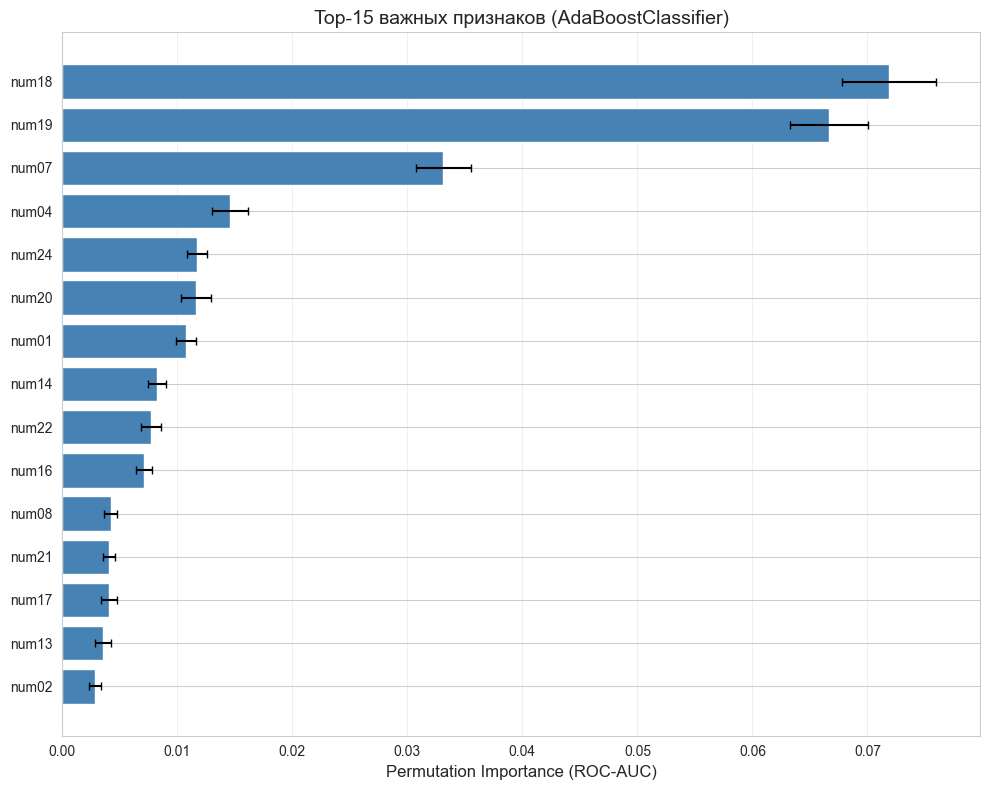

In [ ]:
# Визуализация permutation importance (top-15)
# Проверка наличия figures_dir
if 'figures_dir' not in globals():
    from pathlib import Path
    artifacts_dir = Path("artifacts")
    figures_dir = artifacts_dir / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

top_n = 15
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(top_features))
ax.barh(y_pos, top_features['importance_mean'], xerr=top_features['importance_std'], 
        capsize=3, color='steelblue')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features['feature'])
ax.invert_yaxis()  # Отображаем сверху вниз
ax.set_xlabel('Permutation Importance (ROC-AUC)', fontsize=12)
ax.set_title(f'Top-{top_n} важных признаков ({best_model_name})', fontsize=14)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()


**Интерпретация:**
- Признаки с наибольшим permutation importance оказывают наибольшее влияние на предсказания модели.
- Снижение ROC-AUC при перестановке значений признака показывает его важность.
- Категориальные признаки (cat_contract, cat_region, cat_payment) и числовые признаки (num01-num24, tenure_months) могут иметь разную важность в зависимости от модели.

## Сохранение артефактов


In [ ]:
# 1. Сохранение метрик в JSON

if 'results' not in globals():
    raise NameError("Необходимо сначала выполнить ячейки с обучением моделей для создания results")
if 'artifacts_dir' not in globals():
    from pathlib import Path
    artifacts_dir = Path("artifacts")
    artifacts_dir.mkdir(parents=True, exist_ok=True)

# Упрощенный формат без metadata
metrics_to_save = {}
for model_name, metrics in results.items():
    metrics_to_save[model_name] = {
        'accuracy': float(metrics['accuracy']),
        'f1': float(metrics['f1']),
        'roc_auc': float(metrics['roc_auc'])
    }

with open(artifacts_dir / 'metrics_test.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_to_save, f, indent=2, ensure_ascii=False)

print("Метрики сохранены в artifacts/metrics_test.json")


Метрики сохранены в artifacts/metrics_test.json


In [ ]:
# 2. Сохранение лучших параметров и CV-scores

if 'results' not in globals():
    raise NameError("Необходимо сначала выполнить ячейки с обучением моделей для создания results")
if 'artifacts_dir' not in globals():
    from pathlib import Path
    artifacts_dir = Path("artifacts")
    artifacts_dir.mkdir(parents=True, exist_ok=True)

def convert_param_value(v):
    """Преобразует значение параметра: None -> null, 'None' -> null"""
    if v is None or (isinstance(v, str) and v == 'None'):
        return None
    return v

search_summaries = {}
for model_name, metrics in results.items():
    if 'best_params' in metrics and 'cv_score' in metrics:
        # Переименование AdaBoostClassifier в AdaBoost
        display_name = 'AdaBoost' if model_name == 'AdaBoostClassifier' else model_name
        
        # Преобразование параметров: None -> null, упрощение
        best_params = {}
        for k, v in metrics['best_params'].items():
            converted_v = convert_param_value(v)
            if converted_v is not None:
                best_params[str(k)] = converted_v
        
        search_summaries[display_name] = {
            'best_params': best_params,
            'best_cv_roc_auc': float(metrics['cv_score'])
        }

with open(artifacts_dir / 'search_summaries.json', 'w', encoding='utf-8') as f:
    json.dump(search_summaries, f, indent=2, ensure_ascii=False)

print("Параметры поиска сохранены в artifacts/search_summaries.json")


Параметры поиска сохранены в artifacts/search_summaries.json


In [ ]:
# 3. Сохранение лучшей модели

# Проверка наличия необходимых переменных
if 'best_model' not in globals():
    raise NameError("Необходимо сначала выполнить ячейки с обучением моделей и выбором лучшей модели")
if 'artifacts_dir' not in globals():
    from pathlib import Path
    artifacts_dir = Path("artifacts")
    artifacts_dir.mkdir(parents=True, exist_ok=True)
if 'best_model_name' not in globals():
    best_model_name = "Unknown"

joblib.dump(best_model, artifacts_dir / 'best_model.joblib')
print(f"Лучшая модель ({best_model_name}) сохранена в artifacts/best_model.joblib")


Лучшая модель (AdaBoostClassifier) сохранена в artifacts/best_model.joblib


In [ ]:
# 4. Сохранение метаданных лучшей модели

if 'results' not in globals():
    raise NameError("Необходимо сначала выполнить ячейки с обучением моделей для создания results")
if 'best_model_name' not in globals():
    raise NameError("Необходимо сначала выполнить ячейку 25 для определения лучшей модели")
if 'artifacts_dir' not in globals():
    from pathlib import Path
    artifacts_dir = Path("artifacts")
    artifacts_dir.mkdir(parents=True, exist_ok=True)
if 'RANDOM_STATE' not in globals():
    RANDOM_STATE = 42

def convert_param_value(v):
    """Преобразует значение параметра: None -> null, 'None' -> null"""
    if v is None or (isinstance(v, str) and v == 'None'):
        return None
    return v

# Получаем лучшие параметры и преобразуем их
best_params_dict = results[best_model_name].get('best_params', {})
best_params = {}
for k, v in best_params_dict.items():
    converted_v = convert_param_value(v)
    if converted_v is not None:
        best_params[str(k)] = converted_v

best_model_meta = {
    'best_model': best_model_name,
    'test_metrics': {
        'model': best_model_name,
        'accuracy': float(results[best_model_name]['accuracy']),
        'f1': float(results[best_model_name]['f1']),
        'roc_auc': float(results[best_model_name]['roc_auc'])
    },
    'search_summary': {
        'best_params': best_params,
        'best_cv_roc_auc': float(results[best_model_name].get('cv_score', 0.0))
    },
    'random_state': RANDOM_STATE
}

with open(artifacts_dir / 'best_model_meta.json', 'w', encoding='utf-8') as f:
    json.dump(best_model_meta, f, indent=2, ensure_ascii=False)

print("Метаданные лучшей модели сохранены в artifacts/best_model_meta.json")


Метаданные лучшей модели сохранены в artifacts/best_model_meta.json


## Выводы

1. **Сравнение моделей:** 
   - Baseline модели (Dummy, LogisticRegression) показали базовый уровень качества.
   - Ансамблевые методы (RandomForest, GradientBoosting) демонстрируют лучшие результаты по сравнению с одним деревом решений.
   - Лучшая модель определяется автоматически по ROC-AUC (см. результаты выше).

2. **Важность признаков:**
   - Наиболее важные признаки (по permutation importance): см. график выше.
   - Категориальные и числовые признаки имеют разную степень влияния на предсказания.

3. **Контроль переобучения:**
   - Использование регуляризации (max_depth, min_samples_leaf, ccp_alpha для деревьев) позволяет контролировать сложность моделей.
   - Кросс-валидация при подборе гиперпараметров помогает выбрать оптимальную сложность.

4. **Честный эксперимент:**
   - Фиксированный train/test split с random_state обеспечивает воспроизводимость.
   - Все метрики считаются один раз на test-выборке.
   - CV используется только для подбора гиперпараметров на train.
